In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Entorno configurado correctamente.")

Matplotlib is building the font cache; this may take a moment.


Entorno configurado correctamente.


In [2]:
world= yf.download(
    "URTH",
    start="2015-01-01",
    auto_adjust=True,
    progress=False,
)

In [5]:
world.head()

Price,Close,High,Low,Open,Volume
Ticker,URTH,URTH,URTH,URTH,URTH
Date,,,,,
2015-01-02,57.947811,58.360282,57.527251,58.360282,31100
2015-01-05,56.589108,57.486834,56.500143,56.783209,61100
2015-01-06,55.836964,56.669988,55.820785,56.661899,16300
2015-01-07,56.403103,56.597210,56.111948,56.265615,19200
2015-01-08,57.656677,57.664767,57.292730,57.567713,10000


In [6]:
type(world)

pandas.DataFrame

In [8]:
world.shape
world.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2948 entries, 2015-01-02 to 2026-09-24
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, URTH)   2948 non-null   float64
 1   (High, URTH)    2948 non-null   float64
 2   (Low, URTH)     2948 non-null   float64
 3   (Open, URTH)    2948 non-null   float64
 4   (Volume, URTH)  2948 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 138.2 KB


In [9]:
tickers = ["URTH", "IEMG", "GLD"]

In [11]:
print(tickers)
print(type(tickers))

['URTH', 'IEMG', 'GLD']
<class 'list'>


In [12]:
data = yf.download(
    tickers,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

In [13]:
data.head()

Price            Close                              High             \
Ticker             GLD       IEMG       URTH         GLD       IEMG   
Date                                                                  
2015-01-02  114.080002  34.404827  57.947830  114.800003  34.707595   
2015-01-05  115.800003  33.880527  56.589092  116.000000  34.264527   
2015-01-06  117.120003  33.703297  55.836967  117.500000  34.013451   
2015-01-07  116.430000  34.397449  56.403084  116.879997  34.426986   
2015-01-08  115.940002  35.010380  57.656666  116.870003  35.106380   

Price                         Low                              Open  \
Ticker           URTH         GLD       IEMG       URTH         GLD   
Date                                                                  
2015-01-02  58.360301  112.320000  34.308827  57.527270  112.489998   
2015-01-05  57.486819  114.730003  33.806680  56.500128  114.779999   
2015-01-06  56.669992  115.800003  33.526068  55.820789  116.220001   
2015-01-07  56.597191  116.169998  34.153756  56.111929  116.470001   
2015-01-08  57.664755  115.849998  34.825765  57.292719  116.449997   

Price                               Volume                      
Ticker           IEMG       URTH       GLD       IEMG     URTH  
Date                                                            
2015-01-02  34.678056  58.360301   7109600  3759600.0  31100.0  
2015-01-05  34.220218  56.783193   8177400  2753500.0  61100.0  
2015-01-06  33.902681  56.661903  11238300  3063900.0  16300.0  
2015-01-07  34.316218  56.265596   6434200  2111400.0  19200.0  
2015-01-08  34.892226  57.567701   7033700  1520600.0  10000.0

In [14]:
prices=data["Close"]

In [15]:
prices.head()

Ticker,GLD,IEMG,URTH
Date,,,
2015-01-02,114.080002,34.404827,57.947830
2015-01-05,115.800003,33.880527,56.589092
2015-01-06,117.120003,33.703297,55.836967
2015-01-07,116.430000,34.397449,56.403084
2015-01-08,115.940002,35.010380,57.656666


In [16]:
prices=prices.rename(columns={"URTH": "World", "IEMG": "Emerging Markets", "GLD": "Gold"})

In [17]:
prices.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,114.080002,34.404827,57.947830
2015-01-05,115.800003,33.880527,56.589092
2015-01-06,117.120003,33.703297,55.836967
2015-01-07,116.430000,34.397449,56.403084
2015-01-08,115.940002,35.010380,57.656666


In [19]:
print(prices.shape)
prices.info()

(2949, 3)
<class 'pandas.DataFrame'>
DatetimeIndex: 2949 entries, 2015-01-02 to 2026-09-24
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gold              2949 non-null   float64
 1   Emerging Markets  2948 non-null   float64
 2   World             2948 non-null   float64
dtypes: float64(3)
memory usage: 92.2 KB


In [20]:
prices.describe()

Ticker,Gold,Emerging Markets,World
count,2949.000000,2948.000000,2948.000000
mean,181.405585,46.221939,104.107307
std,84.573675,11.391536,40.601469
min,100.500000,26.211014,50.653797
25%,121.440002,38.917166,72.329290
50%,163.000000,44.118322,94.503998
75%,185.639999,51.794469,123.670643
max,495.899994,86.000000,211.509995


In [21]:
prices.isnull().sum()

Ticker
Gold                0
Emerging Markets    1
World               1
dtype: int64

In [22]:
prices[prices.isnull().any(axis=1)]

Ticker,Gold,Emerging Markets,World
Date,,,
2026-09-22,400.070007,NaN,NaN


In [23]:
check = yf.download(
    ["URTH", "IEMG", "GLD"],
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

check["Close"]

Ticker,GLD,IEMG,URTH
Date,,,
2026-09-21,398.380005,83.760002,209.699997
2026-09-22,400.070007,NaN,NaN
2026-09-23,392.880005,82.220001,207.839996


In [24]:
yf.download(
    "URTH",
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

Price,Close,High,Low,Open,Volume
Ticker,URTH,URTH,URTH,URTH,URTH
Date,,,,,
2026-09-21,209.699997,210.020004,208.039993,208.130005,236400
2026-09-23,207.839996,209.360001,207.419998,209.360001,275200


In [25]:
yf.download(
    "IEMG",
    start="2026-09-21",
    end="2026-09-24",
    auto_adjust=True,
    progress=False
)

Price,Close,High,Low,Open,Volume
Ticker,IEMG,IEMG,IEMG,IEMG,IEMG
Date,,,,,
2026-09-21,83.760002,83.889999,82.900002,83.150002,5383600
2026-09-23,82.220001,83.230003,82.050003,83.089996,16463100


In [26]:
prices_clean = prices.dropna()

In [27]:
print("Original dataset:", prices.shape)
print("Clean dataset:", prices_clean.shape)

print("\nMissing values:")
print(prices_clean.isnull().sum())

Original dataset: (2949, 3)
Clean dataset: (2948, 3)

Missing values:
Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64


In [30]:
prices.isnull().mean() * 100

Ticker
Gold                0.00000
Emerging Markets    0.03391
World               0.03391
dtype: float64

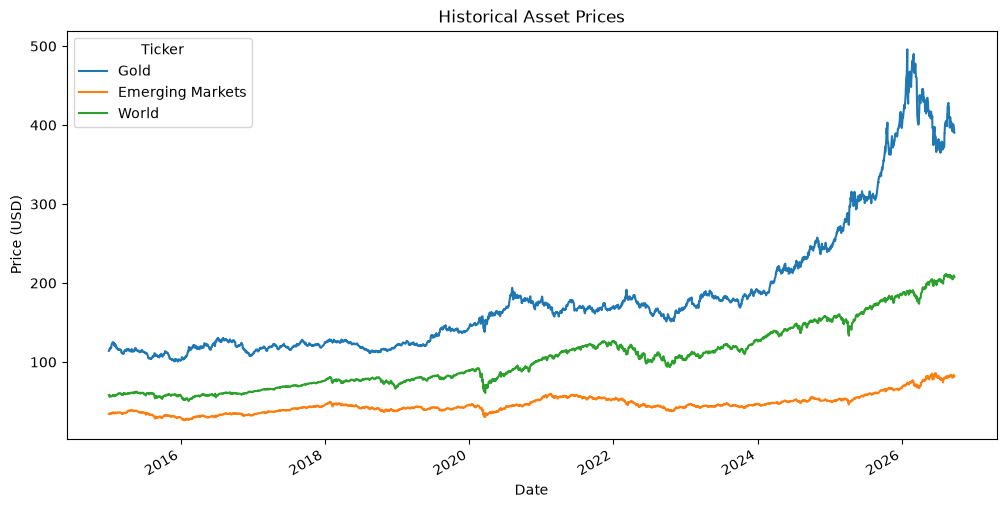

In [32]:
prices_clean.plot(
    figsize=(12, 6),
    title="Historical Asset Prices"
)

plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.show()

In [34]:
returns = prices_clean.pct_change()
returns.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,0.015077,-0.015239,-0.023448
2015-01-06,0.011399,-0.005231,-0.013291
2015-01-07,-0.005891,0.020596,0.010139
2015-01-08,-0.004209,0.017819,0.022225


In [36]:
returns_clean = returns.dropna()
returns_clean.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,0.015077,-0.015239,-0.023448
2015-01-06,0.011399,-0.005231,-0.013291
2015-01-07,-0.005891,0.020596,0.010139
2015-01-08,-0.004209,0.017819,0.022225
2015-01-09,0.011385,-0.003586,-0.009538


In [37]:
returns_clean.isnull().sum()

Ticker
Gold                0
Emerging Markets    0
World               0
dtype: int64

In [38]:
prices_clean["World"].head(2)

Date
2015-01-02    57.947830
2015-01-05    56.589092
Name: World, dtype: float64

In [39]:
manual_return = (
    prices_clean["World"].iloc[1] /
    prices_clean["World"].iloc[0]
) - 1

print(manual_return)

-0.0234476069399413


In [40]:
print("Manual:", manual_return)
print("Pandas:", returns_clean["World"].iloc[0])

Manual: -0.0234476069399413
Pandas: -0.0234476069399413


In [42]:
returns_pct=returns_clean * 100
returns_pct.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,1.507715,-1.523913,-2.344761
2015-01-06,1.139896,-0.523105,-1.329099
2015-01-07,-0.589141,2.059599,1.013874
2015-01-08,-0.420852,1.781906,2.222542
2015-01-09,1.138520,-0.358606,-0.953835


In [43]:
returns_clean.describe()

Ticker,Gold,Emerging Markets,World
count,2947.000000,2947.000000,2947.000000
mean,0.000470,0.000377,0.000491
std,0.010229,0.012891,0.010772
min,-0.102742,-0.126741,-0.113776
25%,-0.004812,-0.006225,-0.003952
50%,0.000565,0.000682,0.000838
75%,0.005617,0.007499,0.005705
max,0.063587,0.074888,0.090963


In [49]:
daily_volatility = returns_clean.std()
print("Normal daily volatility:", daily_volatility)
print("Percentage:", daily_volatility * 100)

Normal daily volatility: Ticker
Gold                0.010229
Emerging Markets    0.012891
World               0.010772
dtype: float64
Percentage: Ticker
Gold                1.022875
Emerging Markets    1.289111
World               1.077192
dtype: float64


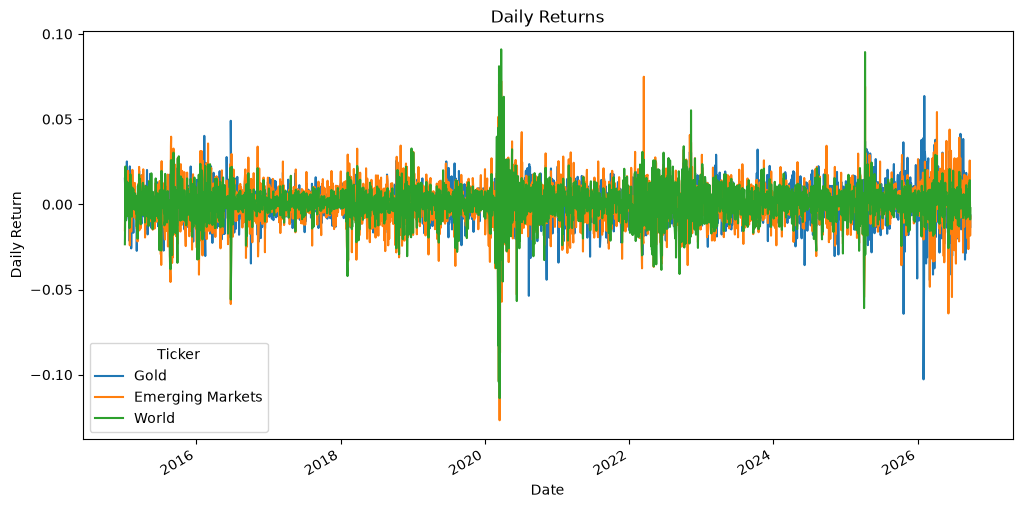

In [50]:
returns_clean.plot(
    figsize=(12, 6),
    title="Daily Returns"
)

plt.ylabel("Daily Return")
plt.xlabel("Date")
plt.show()

In [52]:
cumulative_returns = (1 + returns_clean).cumprod()
cumulative_returns.head()

Ticker,Gold,Emerging Markets,World
Date,,,
2015-01-05,1.015077,0.984761,0.976552
2015-01-06,1.026648,0.979610,0.963573
2015-01-07,1.020600,0.999786,0.973342
2015-01-08,1.016304,1.017601,0.994975
2015-01-09,1.027875,1.013952,0.985485


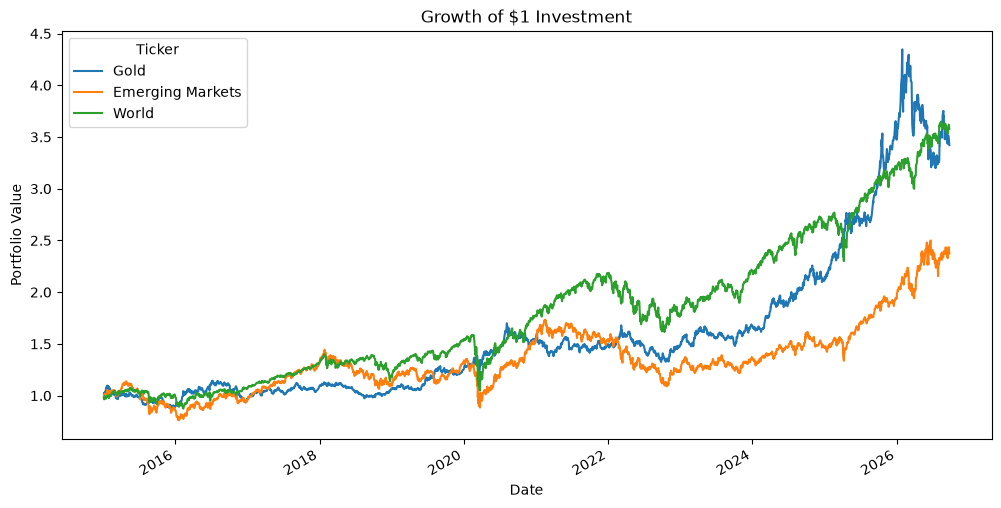

In [53]:
cumulative_returns.plot(
    figsize=(12, 6),
    title="Growth of $1 Investment"
)

plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.show()

In [54]:
cumulative_returns.tail(1)

Ticker,Gold,Emerging Markets,World
Date,,,
2026-09-24,3.421809,2.372778,3.57865


In [56]:
total_returns = (cumulative_returns.iloc[-1] - 1) * 100

print("Total return:", total_returns)

Total return: Ticker
Gold                242.180907
Emerging Markets    137.277757
World               257.864996
Name: 2026-09-24 00:00:00, dtype: float64


In [57]:
start_date = prices_clean.index[0]
end_date = prices_clean.index[-1]

years = (end_date - start_date).days / 365.25

print("Start:", start_date)
print("End:", end_date)
print("Years:", years)

Start: 2015-01-02 00:00:00
End: 2026-09-24 00:00:00
Years: 11.72621492128679


In [59]:
final_values = cumulative_returns.iloc[-1]

cagr = final_values ** (1 / years) - 1

print("CAGR:", cagr * 100)

CAGR: Ticker
Gold                11.060802
Emerging Markets     7.646905
World               11.486075
Name: 2026-09-24 00:00:00, dtype: float64


In [60]:
annual_volatility = returns_clean.std() * np.sqrt(252)

annual_volatility * 100

Ticker
Gold                16.237638
Emerging Markets    20.463996
World               17.099893
dtype: float64

In [61]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "CAGR (%)": cagr * 100,
    "Annual Volatility (%)": annual_volatility * 100
})

summary

,Total Return (%),CAGR (%),Annual Volatility (%)
Ticker,,,
Gold,242.180907,11.060802,16.237638
Emerging Markets,137.277757,7.646905,20.463996
World,257.864996,11.486075,17.099893


In [62]:
correlation_matrix = returns_clean.corr()

correlation_matrix

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,1.000000,0.213718,0.112141
Emerging Markets,0.213718,1.000000,0.803383
World,0.112141,0.803383,1.000000


In [63]:
cov_matrix_daily = returns_clean.cov()

cov_matrix_daily

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.000105,0.000028,0.000012
Emerging Markets,0.000028,0.000166,0.000112
World,0.000012,0.000112,0.000116


In [64]:
cov_matrix_annual = cov_matrix_daily * 252

cov_matrix_annual

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.026366,0.007102,0.003114
Emerging Markets,0.007102,0.041878,0.028113
World,0.003114,0.028113,0.029241


In [68]:
weights = pd.Series({
    "Gold": 0.10,
    "Emerging Markets": 0.20,
    "World": 0.70
})

weights

Gold                0.1
Emerging Markets    0.2
World               0.7
dtype: float64

In [70]:
portfolio_returns = returns_clean @ weights
portfolio_returns.head()

Date
2015-01-05   -0.017953
2015-01-06   -0.009210
2015-01-07    0.010627
2015-01-08    0.018701
2015-01-09   -0.006256
dtype: float64

In [72]:
type(portfolio_returns)

pandas.Series

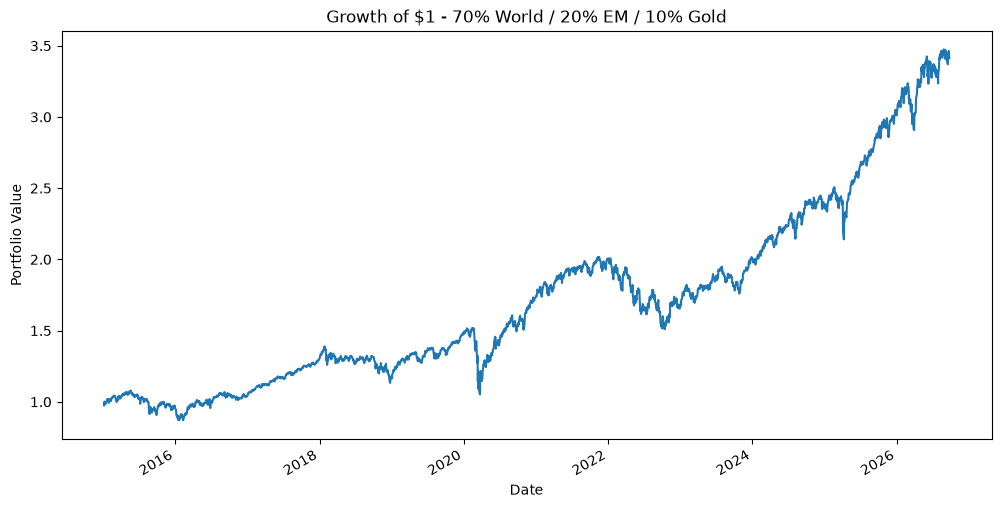

In [75]:
portfolio_growth = (1 + portfolio_returns).cumprod()
portfolio_growth.plot(
    figsize=(12, 6),
    title="Growth of $1 - 70% World / 20% EM / 10% Gold"
)

plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.show()

In [77]:
portfolio_growth.iloc[-1]

np.float64(3.4118201460066717)

In [79]:
portfolio_total_return = (portfolio_growth.iloc[-1] - 1) * 100

print("Total Return:", portfolio_total_return)

Total Return: 241.18201460066717


In [81]:
portfolio_cagr = portfolio_growth.iloc[-1] ** (1 / years) - 1

print("CAGR:", portfolio_cagr * 100)

CAGR: 11.033116402453146


In [82]:
portfolio_volatility = portfolio_returns.std() * np.sqrt(252)

print("Annual Volatility:", portfolio_volatility * 100)

Annual Volatility: 15.766508353259265


In [83]:
portfolio_variance = weights @ cov_matrix_annual @ weights

portfolio_volatility_matrix = np.sqrt(portfolio_variance)

print(portfolio_volatility_matrix * 100)

15.766508353259265


In [85]:
portfolio_sharpe = portfolio_cagr / portfolio_volatility

print("Portfolio Sharpe:", portfolio_sharpe)

Portfolio Sharpe: 0.6997818512031152


In [90]:
portfolio_summary = pd.Series({
    "Total Return (%)": portfolio_total_return,
    "CAGR (%)": portfolio_cagr * 100,
    "Annual Volatility (%)": portfolio_volatility * 100,
    "Sharpe (Rf=0)": portfolio_sharpe
})

portfolio_summary

Total Return (%)         241.182015
CAGR (%)                  11.033116
Annual Volatility (%)     15.766508
Sharpe (Rf=0)              0.699782
dtype: float64

In [93]:
asset_sharpe = summary["CAGR (%)"] / summary["Annual Volatility (%)"]
asset_sharpe

Ticker
Gold                0.681183
Emerging Markets    0.373676
World               0.671705
dtype: float64

In [95]:
summary["Sharpe (Rf=0)"] = asset_sharpe

summary

,Total Return (%),CAGR (%),Annual Volatility (%),Sharpe (Rf=0)
Ticker,,,,
Gold,242.180907,11.060802,16.237638,0.681183
Emerging Markets,137.277757,7.646905,20.463996,0.373676
World,257.864996,11.486075,17.099893,0.671705


In [97]:
annual_mean_return = returns_clean.mean() * 252

asset_sharpe = annual_mean_return / annual_volatility

asset_sharpe

Ticker
Gold                0.729379
Emerging Markets    0.463954
World               0.723611
dtype: float64

In [99]:
portfolio_annual_mean_return = portfolio_returns.mean() * 252

portfolio_sharpe = (
    portfolio_annual_mean_return /
    portfolio_volatility
)

portfolio_sharpe

np.float64(0.7449192270029749)

In [101]:
annual_mean_return = returns_clean.mean() * 252
annual_mean_return

Ticker
Gold                0.118434
Emerging Markets    0.094944
World               0.123737
dtype: float64

In [103]:
cov_matrix_annual = returns_clean.cov() * 252
cov_matrix_annual

Ticker,Gold,Emerging Markets,World
Ticker,,,
Gold,0.026366,0.007102,0.003114
Emerging Markets,0.007102,0.041878,0.028113
World,0.003114,0.028113,0.029241


In [107]:
random_weights = np.random.random(3)
random_weights = random_weights / np.sum(random_weights)
random_weights

array([0.37555836, 0.45097843, 0.1734632 ])

In [108]:
random_return = random_weights @ annual_mean_return

random_return

np.float64(0.1087600789296003)

In [110]:
random_volatility = np.sqrt(
    random_weights @ cov_matrix_annual @ random_weights
)

random_volatility

np.float64(0.1425672921957321)

In [111]:
random_sharpe = random_return / random_volatility

random_sharpe

np.float64(0.7628683778343945)

In [113]:
np.random.seed(42)

n_portfolios = 10000

portfolio_results = []

for i in range(n_portfolios):

    weights_random = np.random.random(3)
    weights_random = weights_random / weights_random.sum()

    portfolio_return_random = weights_random @ annual_mean_return

    portfolio_volatility_random = np.sqrt(
        weights_random @ cov_matrix_annual @ weights_random
    )

    portfolio_sharpe_random = (
        portfolio_return_random /
        portfolio_volatility_random
    )

    portfolio_results.append({
        "Gold Weight": weights_random[0],
        "Emerging Markets Weight": weights_random[1],
        "World Weight": weights_random[2],
        "Return": portfolio_return_random,
        "Volatility": portfolio_volatility_random,
        "Sharpe": portfolio_sharpe_random
    })

In [115]:
portfolios = pd.DataFrame(portfolio_results)
portfolios.head()

,Gold Weight,Emerging Markets Weight,World Weight,Return,Volatility,Sharpe
0,0.182059,0.462129,0.355812,0.109465,0.156087,0.701310
1,0.657381,0.171323,0.171296,0.115318,0.132031,0.873414
2,0.038078,0.567845,0.394077,0.107185,0.176253,0.608131
3,0.416865,0.012119,0.571017,0.121177,0.126749,0.956039
4,0.678655,0.173111,0.148234,0.115153,0.133337,0.863624


In [116]:
portfolios.shape

(10000, 6)

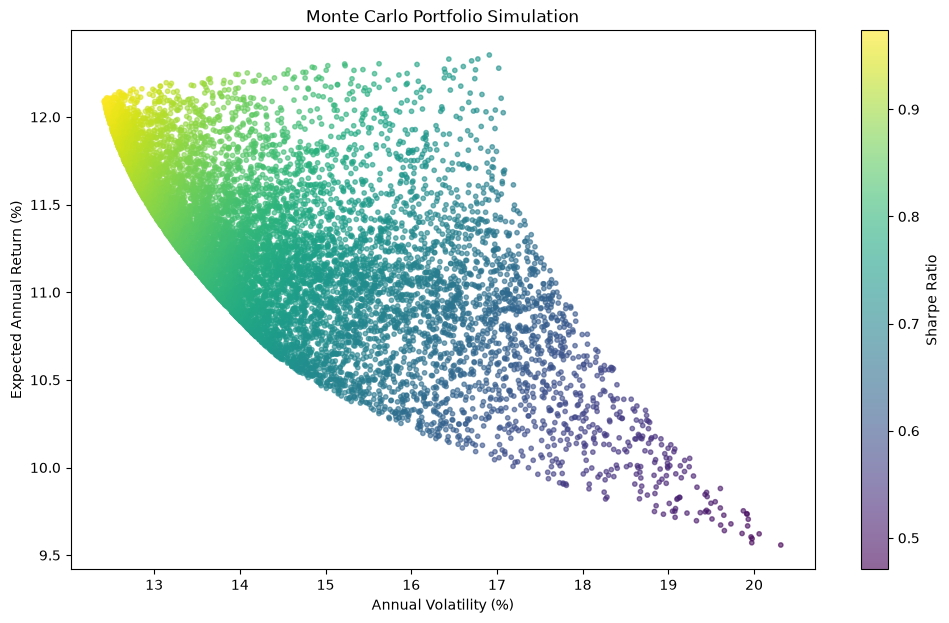

In [117]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6,
    s=10
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(label="Sharpe Ratio")

plt.show()

In [118]:
max_sharpe_idx = portfolios["Sharpe"].idxmax()
max_sharpe_portfolio = portfolios.loc[max_sharpe_idx]

max_sharpe_portfolio

Gold Weight                0.520002
Emerging Markets Weight    0.001955
World Weight               0.478044
Return                     0.120923
Volatility                 0.124205
Sharpe                     0.973576
Name: 1376, dtype: float64

In [119]:
min_vol_idx = portfolios["Volatility"].idxmin()
min_vol_portfolio = portfolios.loc[min_vol_idx]

min_vol_portfolio

Gold Weight                0.527613
Emerging Markets Weight    0.002441
World Weight               0.469946
Return                     0.120869
Volatility                 0.124196
Sharpe                     0.973210
Name: 640, dtype: float64

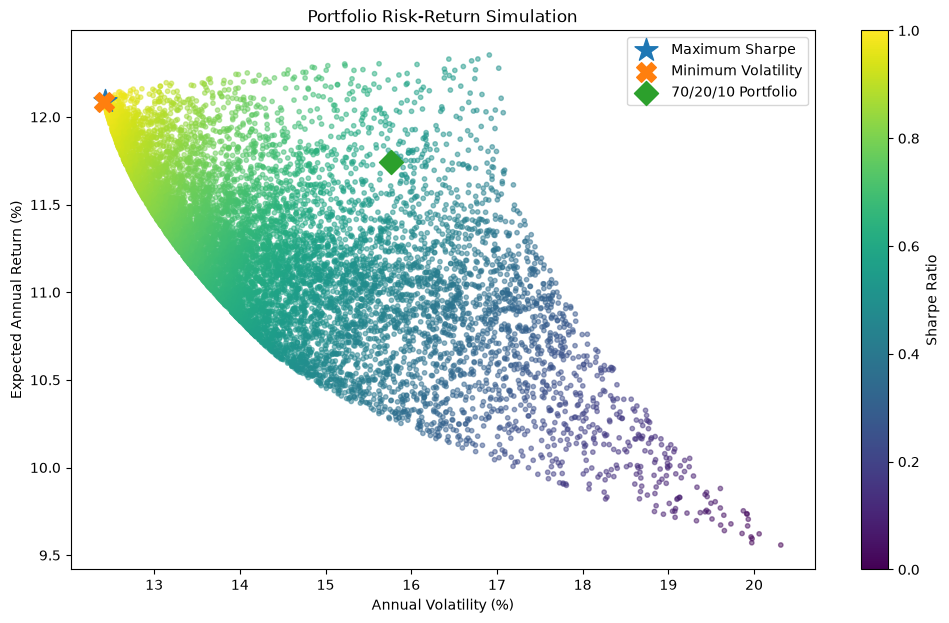

In [121]:
plt.figure(figsize=(12, 7))

plt.scatter(
    portfolios["Volatility"] * 100,
    portfolios["Return"] * 100,
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=10
)

plt.scatter(
    max_sharpe_portfolio["Volatility"] * 100,
    max_sharpe_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    min_vol_portfolio["Volatility"] * 100,
    min_vol_portfolio["Return"] * 100,
    marker="X",
    s=200,
    label="Minimum Volatility"
)
plt.scatter(
    portfolio_volatility * 100,
    portfolio_annual_mean_return * 100,
    marker="D",
    s=150,
    label="70/20/10 Portfolio"
)

plt.xlabel("Annual Volatility (%)")
plt.ylabel("Expected Annual Return (%)")
plt.title("Portfolio Risk-Return Simulation")

plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()

In [122]:
print("Maximum Sharpe weights:")
print(
    max_sharpe_portfolio[
        ["Gold Weight", "Emerging Markets Weight", "World Weight"]
    ] * 100
)

print("\nMinimum Volatility weights:")
print(
    min_vol_portfolio[
        ["Gold Weight", "Emerging Markets Weight", "World Weight"]
    ] * 100
)

Maximum Sharpe weights:
Gold Weight                52.000159
Emerging Markets Weight     0.195485
World Weight               47.804356
Name: 1376, dtype: float64

Minimum Volatility weights:
Gold Weight                52.761268
Emerging Markets Weight     0.244099
World Weight               46.994633
Name: 640, dtype: float64


In [123]:
print("MAXIMUM SHARPE PORTFOLIO")
print("Return:", max_sharpe_portfolio["Return"] * 100)
print("Volatility:", max_sharpe_portfolio["Volatility"] * 100)
print("Sharpe:", max_sharpe_portfolio["Sharpe"])

print("\nMINIMUM VOLATILITY PORTFOLIO")
print("Return:", min_vol_portfolio["Return"] * 100)
print("Volatility:", min_vol_portfolio["Volatility"] * 100)
print("Sharpe:", min_vol_portfolio["Sharpe"])

MAXIMUM SHARPE PORTFOLIO
Return: 12.092291137223956
Volatility: 12.420486495320276
Sharpe: 0.9735762879964505

MINIMUM VOLATILITY PORTFOLIO
Return: 12.08685538857243
Volatility: 12.419571961651615
Sharpe: 0.9732103027297135


In [124]:
from scipy.optimize import minimize

In [126]:
expected_returns = returns_clean.mean() * 252
cov_matrix = returns_clean.cov() * 252
def portfolio_return(weights):
    return weights @ expected_returns.values

def portfolio_volatility(weights):
    return np.sqrt(
        weights @ cov_matrix @ weights
        )

In [127]:
test_weights = np.array([0.5, 0.0, 0.5])

print(portfolio_return(test_weights))
print(portfolio_volatility(test_weights))

0.12108526150359324
0.12433238109795162


In [129]:
n_assets = len(expected_returns)

initial_weights = np.ones(n_assets) / n_assets
initial_weights

array([0.33333333, 0.33333333, 0.33333333])

In [130]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

In [131]:
bounds = tuple(
    (0, 1) for _ in range(n_assets)
)

In [134]:
min_vol_result = minimize(
    portfolio_volatility,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
min_vol_result
min_vol_weights = min_vol_result.x

min_vol_weights

array([5.29133561e-01, 1.72388145e-17, 4.70866439e-01])

In [135]:
min_vol_exact = pd.Series(
    min_vol_weights,
    index=returns_clean.columns
)

min_vol_exact * 100

Ticker
Gold                5.291336e+01
Emerging Markets    1.723881e-15
World               4.708664e+01
dtype: float64

In [136]:
print(
    "Return:",
    portfolio_return(min_vol_weights) * 100
)

print(
    "Volatility:",
    portfolio_volatility(min_vol_weights) * 100
)

Return: 12.093077267612214
Volatility: 12.416403122282151


In [139]:
def negative_sharpe(weights):
    portfolio_ret = portfolio_return(weights)
    portfolio_vol = portfolio_volatility(weights)

    
    return -(portfolio_ret / portfolio_vol)

In [140]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)
max_sharpe_weights = max_sharpe_result.x
max_sharpe_exact = pd.Series(
    max_sharpe_weights,
    index=returns_clean.columns
)

max_sharpe_exact * 100

Ticker
Gold                5.154151e+01
Emerging Markets    9.118140e-15
World               4.845849e+01
dtype: float64

In [141]:
max_sharpe_return = portfolio_return(max_sharpe_weights)

max_sharpe_volatility = portfolio_volatility(max_sharpe_weights)

max_sharpe_ratio = (
    max_sharpe_return /
    max_sharpe_volatility
)

In [142]:
print("Weights:")
print(max_sharpe_exact * 100)

print("\nReturn:", max_sharpe_return * 100)

print("Volatility:", max_sharpe_volatility * 100)

print("Sharpe:", max_sharpe_ratio)

Weights:
Ticker
Gold                5.154151e+01
Emerging Markets    9.118140e-15
World               4.845849e+01
dtype: float64

Return: 12.100351857536463
Volatility: 12.420130172864553
Sharpe: 0.9742532235268563
